In [8]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

CSV_NAME = 'abandono_coop.csv'

def get_csv_path():
    for directory in (Path.cwd(), *Path.cwd().parents):
        candidate = directory / CSV_NAME
        if candidate.is_file():
            return candidate

    candidate = next(Path.cwd().rglob(CSV_NAME), None)
    if candidate is not None:
        return candidate

    try:
        from google.colab import files
    except ImportError as error:
        raise FileNotFoundError(
            f'No se encontró {CSV_NAME} en el directorio de trabajo.'
        ) from error

    uploaded = files.upload()
    if CSV_NAME not in uploaded:
        raise FileNotFoundError(
            f'Seleccioná el archivo {CSV_NAME} para continuar.'
        )
    return Path(CSV_NAME)

In [ ]:
df = pd.read_csv(get_csv_path())

PermissionError: [Errno 13] Permission denied: 'D:\\Facultad\\facultad_git\\Laboratorio AI\\LabAI'

Realizamos el análisis exploratorio de los datos (EDA): estudiar la distribución de cada variable (histogramas, con-
teos por categoría, valores atípicos) y explorar si existen relaciones entre variables (correlaciones, gráficos de
dispersión, tablas cruzadas).


In [ ]:
CODIGOS_FALTANTES = ['', ' ', 'N/D', 'n/d', 's/d', 'S/D', '-', '--', 'NULL', 'sin dato']

df = pd.read_csv(get_csv_path(),
    sep=';',
    decimal=',',
    na_values=CODIGOS_FALTANTES,
)
print("Filas:", df.shape[0], "| Columnas:", df.shape[1])
df.head(10)

Filas: 1212 | Columnas: 18


,nro_socio,fecha_alta,localidad,tarifa,consumo_prom_kwh,variacion_consumo_%,antiguedad_meses,cant_reclamos,cortes_ultimo_anio,horas_sin_servicio,facturas_emitidas,facturas_vencidas,medidor_inteligente,adhesion_debito,edad_titular,canal_contacto,codigo_postal,estado
0,100574,2021-11-22,Trenel,Residencial,127.0,30.9,52,2.0,2,"10,4 hs",12,0,No,Sí,31,Web,NaN,Activo
1,100808,01/12/2025,Intendente Alvear,Comercial,-99.0,11.7,3,1.0,2,"8,5 hs",12,1,NaN,Sí,65,App,NaN,Activo
2,101054,24/08/2021,Intendente Alvear,Residencial,226.0,14.5,55,0.0,3,"15,9 hs",12,0,No,No,63,Teléfono,NaN,Activo
3,101087,2020-05-01,Intendente Alvear,Comercial,359.0,46.7,71,0.0,4,"6,0 hs",12,2,Sí,No,78,App,NaN,Activo
4,100779,2009-07-28,Intendente Alvear,Residencial,232.0,9.5,202,2.0,3,"7,6 hs",12,0,No,Sí,54,Web,NaN,Activo
5,101172,2001-06-10,Trenel,Rural,84.0,-7.8,301,NaN,1,"1,6 hs",12,0,No,No,27,Web,NaN,Activo
6,100518,29/11/2014,Eduardo Castex,Comercial,198.0,-4.4,137,1.0,1,"3,0 hs",12,1,No,No,61,App,NaN,Baja
7,100281,2025-03-06,Realicó,Residencial,191.0,-8.0,12,1.0,0,"0,0 hs",12,0,NaN,No,59,Web,NaN,Activo
8,100563,21/02/1999,General Pico,RURAL,658.0,-36.0,329,1.0,2,"4,4 hs",12,0,NaN,Sí,33,App,NaN,Activo
9,100520,2013-08-06,Intendente Alvear,Rural,125.0,29.9,153,0.0,2,"3,6 hs",12,0,Sí,No,50,App,NaN,Activo


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1212 entries, 0 to 1211
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   nro_socio            1212 non-null   int64  
 1   fecha_alta           1180 non-null   str    
 2   localidad            1212 non-null   str    
 3   tarifa               1212 non-null   str    
 4   consumo_prom_kwh     1186 non-null   float64
 5   variacion_consumo_%  1149 non-null   float64
 6   antiguedad_meses     1212 non-null   int64  
 7   cant_reclamos        1029 non-null   float64
 8   cortes_ultimo_anio   1212 non-null   int64  
 9   horas_sin_servicio   1212 non-null   str    
 10  facturas_emitidas    1212 non-null   int64  
 11  facturas_vencidas    1212 non-null   int64  
 12  medidor_inteligente  745 non-null    str    
 13  adhesion_debito      1212 non-null   str    
 14  edad_titular         1212 non-null   int64  
 15  canal_contacto       1212 non-null   str    
 16 

In [ ]:
df.dtypes

nro_socio                int64
fecha_alta                 str
localidad                  str
tarifa                     str
consumo_prom_kwh       float64
variacion_consumo_%    float64
antiguedad_meses         int64
cant_reclamos          float64
cortes_ultimo_anio       int64
horas_sin_servicio         str
facturas_emitidas        int64
facturas_vencidas        int64
medidor_inteligente        str
adhesion_debito            str
edad_titular             int64
canal_contacto             str
codigo_postal          float64
estado                     str
dtype: object

In [ ]:
df.columns = (df.columns
              .str.strip()                                  # saca espacios al borde
              .str.lower()                                  # todo en minuscula
              .str.replace('%', 'pct', regex=False)         # simbolos fuera
              .str.replace(' ', '_', regex=False))          # espacios internos -> _

list(df.columns)

['nro_socio',
 'fecha_alta',
 'localidad',
 'tarifa',
 'consumo_prom_kwh',
 'variacion_consumo_pct',
 'antiguedad_meses',
 'cant_reclamos',
 'cortes_ultimo_anio',
 'horas_sin_servicio',
 'facturas_emitidas',
 'facturas_vencidas',
 'medidor_inteligente',
 'adhesion_debito',
 'edad_titular',
 'canal_contacto',
 'codigo_postal',
 'estado']

In [ ]:
faltantes = pd.DataFrame({
    'faltantes': df.isna().sum(),
    'porcentaje': (df.isna().mean() * 100).round(1),
}).sort_values('porcentaje', ascending=False)

faltantes

,faltantes,porcentaje
codigo_postal,1011,83.4
medidor_inteligente,467,38.5
cant_reclamos,183,15.1
variacion_consumo_pct,63,5.2
fecha_alta,32,2.6
consumo_prom_kwh,26,2.1
nro_socio,0,0.0
antiguedad_meses,0,0.0
localidad,0,0.0
tarifa,0,0.0


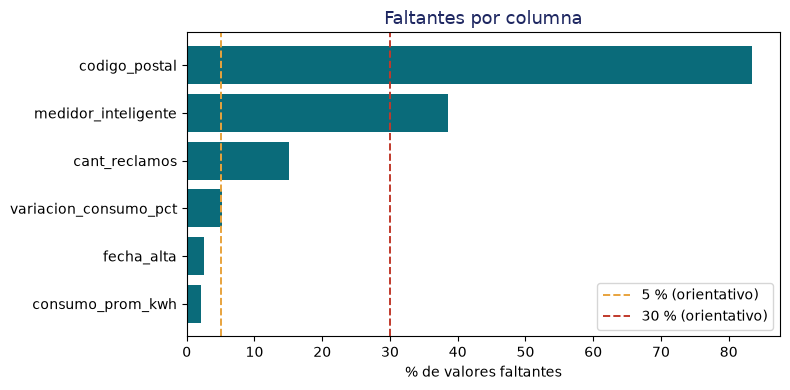

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

sin_ceros = faltantes[faltantes['porcentaje'] > 0].sort_values('porcentaje')

ax.barh(sin_ceros.index, sin_ceros['porcentaje'], color='#0A6B7A')
ax.axvline(5,  color='#E8A33D', linestyle='--', linewidth=1.4, label='5 % (orientativo)')
ax.axvline(30, color='#C0392B', linestyle='--', linewidth=1.4, label='30 % (orientativo)')
ax.set_xlabel('% de valores faltantes')
ax.set_title('Faltantes por columna', fontsize=13, color='#1E2761')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
print("Filas duplicadas exactas:", df.duplicated().sum())
df[df.duplicated(keep=False)].sort_values('fecha_alta').head(6)

Filas duplicadas exactas: 12


,nro_socio,fecha_alta,localidad,tarifa,consumo_prom_kwh,variacion_consumo_pct,antiguedad_meses,cant_reclamos,cortes_ultimo_anio,horas_sin_servicio,facturas_emitidas,facturas_vencidas,medidor_inteligente,adhesion_debito,edad_titular,canal_contacto,codigo_postal,estado
215,100432,11/06/2018,Eduardo Castex,Residencial,168.0,8.8,94,0.0,2,"10,2 hs",12,1,NaN,Sí,26,Web,NaN,Baja
874,100432,11/06/2018,Eduardo Castex,Residencial,168.0,8.8,94,0.0,2,"10,2 hs",12,1,NaN,Sí,26,Web,NaN,Baja
896,100345,13/03/2018,Eduardo Castex,Residencial,101.0,2.2,97,1.0,2,"4,5 hs",12,0,No,Sí,72,Teléfono,NaN,Baja
935,100345,13/03/2018,Eduardo Castex,Residencial,101.0,2.2,97,1.0,2,"4,5 hs",12,0,No,Sí,72,Teléfono,NaN,Baja
688,100888,17/01/2000,Trenel,residencial,483.0,-16.5,318,0.0,0,"0,0 hs",12,0,NaN,Sí,55,App,NaN,Activo
991,100888,17/01/2000,Trenel,residencial,483.0,-16.5,318,0.0,0,"0,0 hs",12,0,NaN,Sí,55,App,NaN,Activo


In [ ]:
antes = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"{antes} -> {len(df)} filas  ({antes - len(df)} eliminadas)")

1212 -> 1200 filas  (12 eliminadas)


In [ ]:
f_iso = pd.to_datetime(df['fecha_alta'], format='%Y-%m-%d', errors='coerce')   
f_arg = pd.to_datetime(df['fecha_alta'], format='%d/%m/%Y', errors='coerce')   

print("Interpretadas como ISO:", f_iso.notna().sum())
print("Interpretadas como dd/mm/aaaa:", f_arg.notna().sum())

df['fecha'] = f_iso.fillna(f_arg)          
print("\nTipo resultante:", df['fecha_alta'].dtype)
print("Fechas que quedaron vacias (NaT):", df['fecha_alta'].isna().sum())

Interpretadas como ISO: 645
Interpretadas como dd/mm/aaaa: 523

Tipo resultante: str
Fechas que quedaron vacias (NaT): 32


Unificamos las localidades escritas de distintas maneras a (ejemplo):	'Gral. Pico' to 'General pico'

In [ ]:
df['localidad'].value_counts()

localidad
Realicó              222
Trenel               196
Intendente Alvear    189
Eduardo Castex       125
General Pico         123
Santa Rosa           110
eduardo castex        39
E. Castex             32
GENERAL PICO          30
general pico          30
Sta. Rosa             27
SANTA ROSA            27
Gral. Pico            27
santa rosa            23
Name: count, dtype: int64

In [ ]:
df['localidad'] = (df['localidad']
                  .str.strip()                              # espacios al borde
                  .str.lower()                              # unifica mayusculas
                  .str.replace(r'\s+', ' ', regex=True)     # espacios dobles -> uno
                  .replace({'gral. pico': 'General Pico', 'e. castex' : 'Eduardo Castex', 'sta. rosa' : 'Santa Rosa'})
                                                        # abreviatura conocida
                  .str.title())                             # General Pico

df['localidad'].value_counts()

localidad
Realicó              222
General Pico         210
Trenel               196
Eduardo Castex       196
Intendente Alvear    189
Santa Rosa           187
Name: count, dtype: int64

In [ ]:
df['tarifa'].value_counts()

tarifa
Residencial     467
Comercial       240
RESIDENCIAL     112
Resid.          110
Rural           104
residencial      97
RURAL            38
rural            32
Name: count, dtype: int64

In [ ]:
df['tarifa'] = (df['tarifa']
                  .str.strip()                              # espacios al borde
                  .str.lower()                              # unifica mayusculas
                  .str.replace(r'\s+', ' ', regex=True)# espacios dobles -> uno
                  .replace({'rural': 'Rural', 'resid.' : 'Residencial'})
                                                        # abreviatura conocida
                  .str.title())                             # General Pico

df['tarifa'].value_counts()

tarifa
Residencial    786
Comercial      240
Rural          174
Name: count, dtype: int64

In [ ]:
df['horas_sin_servicio'] = (df['horas_sin_servicio']
                    .str.replace(' hs', '', regex=False)
                    .str.strip()
                    .str.replace(',', '.', regex=False)
                    .astype(float))

df['horas_sin_servicio'].describe().round(2)

count    1200.00
mean        8.01
std         6.87
min         0.00
25%         2.90
50%         5.80
75%        11.42
max        35.50
Name: horas_sin_servicio, dtype: float64

In [ ]:
df['consumo_prom_kwh'].value_counts()

consumo_prom_kwh
-99.0     48
 180.0     9
 223.0     8
 168.0     8
 231.0     8
          ..
 474.0     1
 53.0      1
 669.0     1
 64.0      1
 519.0     1
Name: count, Length: 441, dtype: int64

En el apartado de categorias, eliminamos valores centinelas en la columna de promedio de Kw/h. Ya que un valor negativo esta fuera de rango.

In [ ]:
print("Centinelas -99 en consumo_prom_kwh:", (df['consumo_prom_kwh'] == -99).sum())
df['consumo_prom_kwh'] = df['consumo_prom_kwh'].replace(-99, np.nan)

df[['consumo_prom_kwh']].describe().round(2)

Centinelas -99 en consumo_prom_kwh: 48


,consumo_prom_kwh
count,1126.00
mean,275.58
std,149.06
min,53.00
25%,168.00
50%,242.50
75%,346.00
max,1148.00


Luego aplicamos la media para ver que datos son coherentes y que datos no brindan informacion, posteriormente decidimos que hacer con esos datos, tomando como referencia los valores de los calculos.


In [ ]:
pct = (df.isna().mean() * 100).round(1).sort_values(ascending=False)
pct[pct > 0]

codigo_postal            83.4
medidor_inteligente      38.7
cant_reclamos            15.2
consumo_prom_kwh          6.2
variacion_consumo_pct     5.1
fecha_alta                2.7
fecha                     2.7
dtype: float64

 | Columna | % faltante | Decisión | Argumento |
|---|---|---|---|
| `codigo_postal` | ~83 % | **Descartar la columna** | texto libre, sin estructura, casi vacía |
| `medidor_inteligente` | ~38 % | **Conservar e imputar** | supera el 30 % pero es **reconstruible**: se deriva de la temperatura máxima |
| `cant_reclamos` | ~15 % | Imputar con 0 | en registros meteorológicos, "sin dato de lluvia" suele significar que no llovió |
| `consumo_prom_kwh` | ~6 % | Imputar con la mediana **por estación** | cada estación tiene su propio régimen térmico |
| `variacion_consumo_pct` | ~5 % | **Eliminar esas filas** | sin fecha el registro no se puede ubicar en el tiempo |
| `fecha_alta` | ~2 % | Imputar con la mediana | pocos casos, variable estable |
| `fecha` | ~2 % | **Eliminar esas filas** | es la variable objetivo: no se inventa |

In [ ]:
df = df.drop(columns=['codigo_postal', 'fecha'])
print("Columnas restantes:", list(df.columns))

Columnas restantes: ['nro_socio', 'fecha_alta', 'localidad', 'tarifa', 'consumo_prom_kwh', 'variacion_consumo_pct', 'antiguedad_meses', 'cant_reclamos', 'cortes_ultimo_anio', 'horas_sin_servicio', 'facturas_emitidas', 'facturas_vencidas', 'medidor_inteligente', 'adhesion_debito', 'edad_titular', 'canal_contacto', 'estado']


Ahora remplazamos los NA por 0, para verficar que no queden espacios vacios o valores nulos

La función es imputar los valores faltantes y preparar las columnas para que el conjunto de datos quede listo para el modelado.

In [ ]:


    # 1 cant_reclamos: ausencia de registro equivale a 0 reclamos
df['cant_reclamos'] = df['cant_reclamos'].fillna(0)

    # 2 consumo_prom_kwh: mediana por tipo de tarifa (un comercio no consume como un hogar)
df['consumo_prom_kwh'] = df.groupby('tarifa')['consumo_prom_kwh'].transform(lambda s: s.fillna(s.median()))

    # 3 variacion_consumo_pct: mediana global de la variación
df['variacion_consumo_pct'] = df['variacion_consumo_pct'].fillna(df['variacion_consumo_pct'].median())

    # 4 medidor_inteligente: categoría 'Desconocido' (o 'No')
df['medidor_inteligente'] = df['medidor_inteligente'].fillna('Desconocido')

    # 5 Descartamos identificadores y fechas redundantes para el modelo
df = df.drop(columns=['nro_socio', 'fecha_alta'], errors='ignore')

    # 6   Verificamos que no queden valores nulos
df.isna().sum()

localidad                0
tarifa                   0
consumo_prom_kwh         0
variacion_consumo_pct    0
antiguedad_meses         0
cant_reclamos            0
cortes_ultimo_anio       0
horas_sin_servicio       0
facturas_emitidas        0
facturas_vencidas        0
medidor_inteligente      0
adhesion_debito          0
edad_titular             0
canal_contacto           0
estado                   0
dtype: int64

In [ ]:
df.head()

,localidad,tarifa,consumo_prom_kwh,variacion_consumo_pct,antiguedad_meses,cant_reclamos,cortes_ultimo_anio,horas_sin_servicio,facturas_emitidas,facturas_vencidas,medidor_inteligente,adhesion_debito,edad_titular,canal_contacto,estado
0,Trenel,Residencial,127.0,30.9,52,2.0,2,10.4,12,0,No,Sí,31,Web,Activo
1,Intendente Alvear,Comercial,242.5,11.7,3,1.0,2,8.5,12,1,Desconocido,Sí,65,App,Activo
2,Intendente Alvear,Residencial,226.0,14.5,55,0.0,3,15.9,12,0,No,No,63,Teléfono,Activo
3,Intendente Alvear,Comercial,359.0,46.7,71,0.0,4,6.0,12,2,Sí,No,78,App,Activo
4,Intendente Alvear,Residencial,232.0,9.5,202,2.0,3,7.6,12,0,No,Sí,54,Web,Activo


Control de coherencia:

Que no falten datos no significa que los datos sean correctos. Hay reglas del dominio que se pueden verificar: Tomamos como referencia que la cantidad de facturas vencidas, no puede superar a la cantidad de facturas emitidas.

Otro ejemplo es que la edad del titular, si o si, tenga que ser mayor que 18

El promedio de consumo no puede ser menor a 0.



In [ ]:
incoherentes = ((df['facturas_vencidas'] > df['facturas_emitidas']) | (df['edad_titular'] < 18) | (df['consumo_prom_kwh'] < 0) | (df['cant_reclamos'] < 0) | (df['cortes_ultimo_anio'] <0) | (df['horas_sin_servicio']<0))
print("Total de Incoherencias :", incoherentes.sum())
df.loc[incoherentes, ['facturas_vencidas', 'facturas_emitidas', 'edad_titular', 'consumo_prom_kwh', 'cant_reclamos', 'cortes_ultimo_anio', 'horas_sin_servicio']].head()

Total de Incoherencias : 29


,facturas_vencidas,facturas_emitidas,edad_titular,consumo_prom_kwh,cant_reclamos,cortes_ultimo_anio,horas_sin_servicio
178,19,12,50,180.0,1.0,4,14.8
196,15,12,43,473.0,0.0,0,0.0
252,18,12,58,180.0,1.0,3,3.8
281,15,12,39,292.0,2.0,1,3.5
283,18,12,52,212.0,0.0,3,9.1


In [ ]:
print("Facturas vencidas > emitidas:", (df['facturas_vencidas'] > df['facturas_emitidas']).sum())
print("Titulares menores de 18 años:", (df['edad_titular'] < 18).sum())
print("Consumo negativo:",              (df['consumo_prom_kwh'] < 0).sum())
print("Reclamos negativos:",           (df['cant_reclamos'] < 0).sum())
print("Cortes negativos:",             (df['cortes_ultimo_anio'] < 0).sum())
print("Horas sin servicio negativas:", (df['horas_sin_servicio'] < 0).sum())

Facturas vencidas > emitidas: 23
Titulares menores de 18 años: 6
Consumo negativo: 0
Reclamos negativos: 0
Cortes negativos: 0
Horas sin servicio negativas: 0


Datos irrelevantes: Consumo negativo | Reclamos negativos | Cortes Negativos | Horas sin servicio negativas

In [ ]:
print("Filas actuales: ", len(df))

Filas actuales:  1200


In [ ]:
df = df[~incoherentes].reset_index(drop=True)
print("Filas finales:", len(df))

Filas finales: 1171


In [ ]:
    #Integridad estructural
assert df.isna().sum().sum() == 0, "Error: Quedaron valores nulos sin imputar"
assert df.duplicated().sum() == 0, "Error: Quedaron filas duplicadas"

    #Coherencia administrativa
assert (df['facturas_vencidas'] <= df['facturas_emitidas']).all(), "Error: Hay facturas vencidas mayores a las emitidas"

    #Coherencia física y demográfica
assert (df['edad_titular'] >= 18).all(), "Error: Hay titulares menores de 18 años"
assert (df['consumo_prom_kwh'] >= 0).all(), "Error: Hay consumos negativos"
assert (df['cant_reclamos'] >= 0).all(), "Error: Hay reclamos negativos"
assert (df['cortes_ultimo_anio'] >= 0).all(), "Error: Hay cortes de servicio negativos"
assert (df['horas_sin_servicio'] >= 0).all(), "Error: Hay horas sin servicio negativas"

print(f"Dataset 100% verificado: {df.shape[0]} filas x {df.shape[1]} columnas.")

Dataset 100% verificado: 1171 filas x 15 columnas.


Realizar el análisis exploratorio de los datos (EDA):

localidad                0
tarifa                   0
consumo_prom_kwh         0
variacion_consumo_pct    0
antiguedad_meses         0
cant_reclamos            0
cortes_ultimo_anio       0
horas_sin_servicio       0
facturas_emitidas        0
facturas_vencidas        0
medidor_inteligente      0
adhesion_debito          0
edad_titular             0
canal_contacto           0
estado                   0
dtype: int64

In [5]:
col_consumo = df['consumo_prom_kwh']
print("-Medidas de Consumo- ")
print("     media  :", round(col_consumo.mean(), 2))
print("     mediana:", col_consumo.median())
print("     moda   :", col_consumo.mode().tolist())

col_horas_servicio= df['horas_sin_servicio']
print("\n")
print("-Medidas de Horas sin servicio- ")
print("     media  :", round(col_horas_servicio.mean(), 2))
print("     mediana:", col_horas_servicio.median())
print("     moda   :", col_horas_servicio.mode().tolist())
print("\n")
col_cant_recl= df['cant_reclamos']

print("-Medidas de Reclamos- ")
print("     media  :", round(col_cant_recl.mean(), 2))
print("     mediana:", col_cant_recl.median())
print("     moda   :", col_cant_recl.mode().tolist())


NameError: name 'df' is not defined